### Updated QUBO Formulation

$$H = -\sum_i r_i x_i + \lambda_{budget} \left(\sum_i x_i - K\right)^2 + \lambda_{spatial} \sum_{i<j, d_{ij} < N} x_i x_j$$

**New term:** The third term penalizes co-selecting sensors $i$ and $j$ that are within N meters of each other.

### Why This Matters for Phase II
Without spatial separation, all sensors cluster at the single highest-risk pixel is operationally useless.  
With separation, sensors spread across zones, providing distributed early warning coverage.

---

In [1]:
# ── 0. Imports ─────────────────────────────────────────────────────────────────
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# Try geopy, fallback to haversine formula if not available
try:
    from geopy.distance import geodesic
    USE_GEOPY = True
except ImportError:
    print('geopy not found — using haversine formula for distance calculation')
    print('For exact geodesic distances, install: pip install geopy')
    USE_GEOPY = False
    
    def haversine(lat1, lon1, lat2, lon2):
        """Haversine distance in meters (good approximation for short distances)."""
        R = 6371000  # Earth radius in meters
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return R * c
    
    def geodesic(coord1, coord2):
        """Wrapper to match geopy.distance.geodesic API."""
        class Distance:
            def __init__(self, meters):
                self.meters = meters
        return Distance(haversine(coord1[0], coord1[1], coord2[0], coord2[1]))

try:
    import pennylane as qml
    from pennylane import numpy as pnp
    print(f'PennyLane version: {qml.__version__}')
except ImportError:
    print('Install PennyLane: pip install pennylane')

REPO_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
DATA_PROC = os.path.join(REPO_ROOT, 'data', 'processed')
print(f'Repo root: {REPO_ROOT}')
print(f'Distance calculation: {"geopy (exact)" if USE_GEOPY else "haversine (approx)"}')

geopy not found — using haversine formula for distance calculation
For exact geodesic distances, install: pip install geopy
PennyLane version: 0.44.1
Repo root: C:\Users\PhotonUser\My Files\OneDrive\Files\Manzanillo\manzanillo-digital-twin
Distance calculation: haversine (approx)


---
## 1. Load Data (Same as v1)

In [2]:
sensor_path = os.path.join(DATA_PROC, 'optimized_sensor_network.csv')

if os.path.exists(sensor_path):
    df_candidates = pd.read_csv(sensor_path)
else:
    np.random.seed(42)
    n = 25
    lats = np.random.uniform(19.03, 19.18, n)
    lons = np.random.uniform(-104.35, -104.15, n)
    layers = ['Asset_Defense'] * 15 + ['Wildland_Perimeter'] * 10
    df_candidates = pd.DataFrame({'latitude': lats, 'longitude': lons, 'layer': layers,
                                   'sensor_id': [f'SYN_{i:02d}' for i in range(n)]})

# Assign risk scores
risk_map_path = os.path.join(DATA_PROC, 'daily_fire_risk_map.tif')
risk_scores = np.zeros(len(df_candidates))

if os.path.exists(risk_map_path):
    try:
        import rasterio
        with rasterio.open(risk_map_path) as src:
            for i, row in df_candidates.iterrows():
                try:
                    r, c = src.index(row['longitude'], row['latitude'])
                    if 0 <= r < src.height and 0 <= c < src.width:
                        risk_scores[i] = max(0, float(src.read(1)[r, c]))
                except: pass
    except ImportError:
        base = np.random.uniform(10, 60, len(df_candidates))
        boost = np.where(df_candidates['layer'] == 'Wildland_Perimeter', 30, 0)
        risk_scores = np.clip(base + boost, 0, 100)
else:
    base = np.random.uniform(10, 60, len(df_candidates))
    boost = np.where(df_candidates['layer'] == 'Wildland_Perimeter', 30, 0)
    risk_scores = np.clip(base + boost, 0, 100)

r_max = risk_scores.max()
risk_norm = risk_scores / r_max if r_max > 0 else risk_scores
df_candidates['risk_score_raw'] = risk_scores
df_candidates['risk_score_norm'] = risk_norm

N = len(df_candidates)
K_BUDGET = 8
r = risk_norm
lats = df_candidates['latitude'].values
lons = df_candidates['longitude'].values

print(f'Loaded {N} candidates, budget K={K_BUDGET}')
print(df_candidates[['sensor_id','latitude','longitude','layer','risk_score_raw']].head(25))

Loaded 25 candidates, budget K=8
      sensor_id   latitude   longitude               layer  risk_score_raw
0      Asset_00  19.095880 -104.283001       Asset_Defense       34.272892
1      Asset_01  19.027243 -104.274907       Asset_Defense       43.558739
2      Asset_02  19.073800 -104.282905       Asset_Defense       45.828842
3      Asset_03  19.027595 -104.318755       Asset_Defense       41.604408
4      Asset_04  19.085413 -104.284007       Asset_Defense       43.791225
5      Asset_05  19.039865 -104.274916       Asset_Defense        0.000000
6      Asset_06  19.026760 -104.265193       Asset_Defense       42.639122
7      Asset_07  19.010278 -104.270430       Asset_Defense       43.905216
8      Asset_08  19.084790 -104.273327       Asset_Defense       45.384960
9      Asset_09  19.039534 -104.284587       Asset_Defense        0.000000
10     Asset_10  19.039404 -104.265202       Asset_Defense        0.000000
11     Asset_11  19.079929 -104.298072       Asset_Defense       42

---
## 2. Compute Distance Matrix & Identify Close Pairs

In [3]:
# ── 2. Distance matrix ────────────────────────────────────────────────────────
MIN_SEPARATION_M = 2000  # meters
dist_matrix = np.zeros((N, N))

for i in range(N):
    for j in range(i+1, N):
        d = geodesic((lats[i], lons[i]), (lats[j], lons[j])).meters
        dist_matrix[i, j] = d
        dist_matrix[j, i] = d

# Find pairs within MIN_SEPARATION_M
close_pairs = []
for i in range(N):
    for j in range(i+1, N):
        if dist_matrix[i, j] < MIN_SEPARATION_M:
            close_pairs.append((i, j, dist_matrix[i, j]))

print(f'Distance matrix computed: {N}×{N}')
print(f'Minimum separation threshold: {MIN_SEPARATION_M} m')
print(f'Pairs within {MIN_SEPARATION_M}m: {len(close_pairs)}')
if close_pairs:
    print('Sample close pairs:')
    for i, j, d in close_pairs[:5]:
        print(f'  {i:2d} ↔ {j:2d}: {d:.0f} m')

Distance matrix computed: 25×25
Minimum separation threshold: 2000 m
Pairs within 2000m: 39
Sample close pairs:
   0 ↔  4: 1169 m
   0 ↔  8: 1598 m
   0 ↔ 12: 1425 m
   0 ↔ 15: 1875 m
   0 ↔ 18: 1537 m


---
## 3. Build QUBO with Spatial Penalty

In [4]:
# ── 3. Build QUBO Q matrix with spatial penalty ──────────────────────────────
LAMBDA_BUDGET  = 5.0   # budget violation penalty
LAMBDA_SPATIAL = 12.0   # proximity penalty (tune this)

Q = np.zeros((N, N))

# Diagonal: -risk + budget penalty
for i in range(N):
    Q[i, i] = -r[i] + LAMBDA_BUDGET * (1 - 2 * K_BUDGET)

# Off-diagonal: budget penalty + spatial penalty
for i in range(N):
    for j in range(i + 1, N):
        Q[i, j] = 2 * LAMBDA_BUDGET  # base budget penalty
        # Add proximity penalty if within MIN_SEPARATION_M
        if dist_matrix[i, j] < MIN_SEPARATION_M:
            Q[i, j] += 2 * LAMBDA_SPATIAL

constant = LAMBDA_BUDGET * K_BUDGET ** 2

print(f'QUBO built: {N}×{N}')
print(f'λ_budget={LAMBDA_BUDGET}, λ_spatial={LAMBDA_SPATIAL}')
print(f'Close pairs penalty: +{2*LAMBDA_SPATIAL} added to {len(close_pairs)} pairs')
print(f'Q diagonal range: [{Q.diagonal().min():.2f}, {Q.diagonal().max():.2f}]')

# Sample Q[i,j] values
if close_pairs:
    i, j, d = close_pairs[0]
    print(f'Example: Q[{i},{j}] = {Q[i,j]:.2f} (distance {d:.0f}m < {MIN_SEPARATION_M}m → penalized)')

QUBO built: 25×25
λ_budget=5.0, λ_spatial=12.0
Close pairs penalty: +24.0 added to 39 pairs
Q diagonal range: [-76.00, -75.00]
Example: Q[0,4] = 34.00 (distance 1169m < 2000m → penalized)


In [5]:
# ── 3B. Helper functions ─────────────────────────────────────────────────────
def qubo_energy(x, Q, constant=0.0):
    return float(x @ Q @ x) + constant

def solution_stats(x, r, K, label='Solution'):
    selected = np.where(x == 1)[0]
    n_sel = len(selected)
    cov = r[selected].sum()
    E = qubo_energy(x, Q, constant)
    
    # Count proximity violations
    violations = 0
    for i in selected:
        for j in selected:
            if i < j and dist_matrix[i, j] < MIN_SEPARATION_M:
                violations += 1
    
    print(f'{label}:')
    print(f'  Selected: {n_sel} sensors (budget={K}) — {"✅" if n_sel <= K else "❌"} budget')
    print(f'  Coverage: {cov:.4f}')
    print(f'  QUBO energy: {E:.4f}')
    print(f'  Proximity violations (<{MIN_SEPARATION_M}m): {violations} pairs')
    return {'n_selected': n_sel, 'coverage': cov, 'energy': E, 'violations': violations, 'indices': selected}

---
## 4. Benchmarking: Greedy, SA, QAOA (5 seeds each)

In [6]:
# ── 4A. Greedy baseline (deterministic, 1 run) ───────────────────────────────
print('='*60)
print('GREEDY BASELINE')
print('='*60)
t0 = time.time()
greedy_idx = np.argsort(r)[::-1][:K_BUDGET]
x_greedy = np.zeros(N, dtype=int)
x_greedy[greedy_idx] = 1
greedy_time = time.time() - t0
greedy_stats = solution_stats(x_greedy, r, K_BUDGET, 'Greedy')
print(f'Runtime: {greedy_time*1000:.2f} ms\n')

GREEDY BASELINE
Greedy:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.4670
  QUBO energy: 112.5330
  Proximity violations (<2000m): 5 pairs
Runtime: 0.21 ms



In [7]:
# ── 4B. Simulated Annealing (5 seeds) ────────────────────────────────────────
def simulated_annealing_qubo(Q, seed=None, n_steps=50000, T_start=5.0, T_end=0.01):
    if seed is not None:
        np.random.seed(seed)
    N = Q.shape[0]
    x = np.random.randint(0, 2, N)
    E = qubo_energy(x, Q)
    best_x, best_E = x.copy(), E
    temps = np.linspace(T_start, T_end, n_steps)
    for T in temps:
        flip = np.random.randint(N)
        x_new = x.copy()
        x_new[flip] = 1 - x_new[flip]
        E_new = qubo_energy(x_new, Q)
        dE = E_new - E
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            x, E = x_new, E_new
            if E < best_E:
                best_x, best_E = x.copy(), E
    return best_x, best_E

print('='*60)
print('SIMULATED ANNEALING (5 SEEDS)')
print('='*60)
sa_results = []
for seed in range(5):
    t0 = time.time()
    x_sa, E_sa = simulated_annealing_qubo(Q, seed=seed)
    runtime = time.time() - t0
    stats = solution_stats(x_sa, r, K_BUDGET, f'SA seed={seed}')
    stats['runtime'] = runtime
    stats['solution'] = x_sa
    sa_results.append(stats)
    print(f'Runtime: {runtime:.3f}s\n')

sa_cov = [s['coverage'] for s in sa_results]
sa_time = [s['runtime'] for s in sa_results]
sa_viol = [s['violations'] for s in sa_results]
print(f'SA Summary (5 seeds):')
print(f'  Coverage: mean={np.mean(sa_cov):.4f}, std={np.std(sa_cov):.4f}, best={np.max(sa_cov):.4f}')
print(f'  Runtime: mean={np.mean(sa_time):.3f}s, std={np.std(sa_time):.3f}s')
print(f'  Violations: mean={np.mean(sa_viol):.1f}, std={np.std(sa_viol):.1f}\n')

best_sa_idx = np.argmax(sa_cov)
x_sa_best = sa_results[best_sa_idx]['solution']

SIMULATED ANNEALING (5 SEEDS)
SA seed=0:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.3488
  QUBO energy: -7.3488
  Proximity violations (<2000m): 0 pairs
Runtime: 0.952s

SA seed=1:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.3790
  QUBO energy: -7.3790
  Proximity violations (<2000m): 0 pairs
Runtime: 0.924s

SA seed=2:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.3439
  QUBO energy: -7.3439
  Proximity violations (<2000m): 0 pairs
Runtime: 0.945s

SA seed=3:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.3190
  QUBO energy: -7.3190
  Proximity violations (<2000m): 0 pairs
Runtime: 1.150s

SA seed=4:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.3790
  QUBO energy: -7.3790
  Proximity violations (<2000m): 0 pairs
Runtime: 0.935s

SA Summary (5 seeds):
  Coverage: mean=7.3539, std=0.0228, best=7.3790
  Runtime: mean=0.981s, std=0.085s
  Violations: mean=0.0, std=0.0



In [8]:
# ── 4C. QAOA (5 seeds, reduced problem M=12) ─────────────────────────────────
M = 12  # subproblem size
K_sub = 8
P = 2   # QAOA depth
N_STEPS = 60  # optimization steps

top_M_idx = np.argsort(r)[::-1][:M]
r_sub = r[top_M_idx]
lats_sub = lats[top_M_idx]
lons_sub = lons[top_M_idx]

# Build sub-QUBO with spatial penalty
Q_sub = np.zeros((M, M))
for i in range(M):
    Q_sub[i, i] = -r_sub[i] + LAMBDA_BUDGET * (1 - 2 * K_sub)
for i in range(M):
    for j in range(i + 1, M):
        Q_sub[i, j] = 2 * LAMBDA_BUDGET
        d_ij = geodesic((lats_sub[i], lons_sub[i]), (lats_sub[j], lons_sub[j])).meters
        if d_ij < MIN_SEPARATION_M:
            Q_sub[i, j] += 2 * LAMBDA_SPATIAL

# Ising conversion
def qubo_to_ising(Q):
    N = Q.shape[0]
    h = np.zeros(N)
    J = np.zeros((N, N))
    offset = 0.0
    for i in range(N):
        h[i] += Q[i, i] / 2
        offset += Q[i, i] / 2
        for j in range(i + 1, N):
            J[i, j] += Q[i, j] / 4
            h[i] += Q[i, j] / 4
            h[j] += Q[i, j] / 4
            offset += Q[i, j] / 4
    return h, J, offset

h_sub, J_sub, offset_sub = qubo_to_ising(Q_sub)

dev = qml.device('default.qubit', wires=M)

def cost_hamiltonian(h, J):
    coeffs, ops = [], []
    for i in range(len(h)):
        if abs(h[i]) > 1e-10:
            coeffs.append(h[i])
            ops.append(qml.PauliZ(i))
    for i in range(len(J)):
        for j in range(i + 1, len(J)):
            if abs(J[i, j]) > 1e-10:
                coeffs.append(J[i, j])
                ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
    return qml.Hamiltonian(coeffs, ops)

def mixer_hamiltonian(n_qubits):
    return qml.Hamiltonian([-1.0] * n_qubits, [qml.PauliX(i) for i in range(n_qubits)])

H_cost  = cost_hamiltonian(h_sub, J_sub)
H_mixer = mixer_hamiltonian(M)

@qml.qnode(dev)
def qaoa_circuit(params):
    gammas = params[:P]
    betas  = params[P:]
    for i in range(M):
        qml.Hadamard(wires=i)
    for p in range(P):
        qml.CommutingEvolution(H_cost,  gammas[p])
        qml.CommutingEvolution(H_mixer, betas[p])
    return qml.expval(H_cost)

dev_sample = qml.device('default.qubit', wires=M, shots=2000)

@qml.qnode(dev_sample)
def qaoa_sample_circuit(params):
    gammas = params[:P]
    betas  = params[P:]
    for i in range(M):
        qml.Hadamard(wires=i)
    for p in range(P):
        qml.CommutingEvolution(H_cost,  gammas[p])
        qml.CommutingEvolution(H_mixer, betas[p])
    return qml.counts(all_outcomes=False)

print('='*60)
print(f'QAOA (5 SEEDS, M={M} qubits, P={P} layers, {N_STEPS} steps)')
print('='*60)

qaoa_results = []
for seed in range(5):
    np.random.seed(seed)
    init_params = np.random.uniform(0, np.pi, 2 * P)
    opt = qml.GradientDescentOptimizer(stepsize=0.1)
    params = pnp.array(init_params, requires_grad=True)
    
    t0 = time.time()
    for step in range(N_STEPS):
        params, E = opt.step_and_cost(qaoa_circuit, params)
    
    counts = qaoa_sample_circuit(params)
    opt_time = time.time() - t0
    
    # Find best valid bitstring
    best_bitstring, best_E = None, float('inf')
    for bitstring, count in counts.items():
        x = np.array([int(b) for b in str(bitstring)] if isinstance(bitstring, str) else list(bitstring), dtype=int)
        if len(x) != M: continue
        if x.sum() <= K_sub:
            E_bs = qubo_energy(x, Q_sub)
            if E_bs < best_E:
                best_E = E_bs
                best_bitstring = x
    
    if best_bitstring is not None:
        selected_sub = np.where(best_bitstring == 1)[0]
        selected_global = top_M_idx[selected_sub]
        x_qaoa_full = np.zeros(N, dtype=int)
        x_qaoa_full[selected_global] = 1
        stats = solution_stats(x_qaoa_full, r, K_BUDGET, f'QAOA seed={seed}')
        stats['runtime'] = opt_time
        stats['solution'] = x_qaoa_full
        qaoa_results.append(stats)
        print(f'Runtime: {opt_time:.3f}s\n')
    else:
        print(f'QAOA seed={seed}: No valid solution found\n')

if qaoa_results:
    qaoa_cov = [s['coverage'] for s in qaoa_results]
    qaoa_time = [s['runtime'] for s in qaoa_results]
    qaoa_viol = [s['violations'] for s in qaoa_results]
    print(f'QAOA Summary ({len(qaoa_results)} seeds):')
    print(f'  Coverage: mean={np.mean(qaoa_cov):.4f}, std={np.std(qaoa_cov):.4f}, best={np.max(qaoa_cov):.4f}')
    print(f'  Runtime: mean={np.mean(qaoa_time):.3f}s, std={np.std(qaoa_time):.3f}s')
    print(f'  Violations: mean={np.mean(qaoa_viol):.1f}, std={np.std(qaoa_viol):.1f}\n')
    best_qaoa_idx = np.argmax(qaoa_cov)
    x_qaoa_best = qaoa_results[best_qaoa_idx]['solution']
else:
    x_qaoa_best = None

QAOA (5 SEEDS, M=12 qubits, P=2 layers, 60 steps)
QAOA seed=0:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.2866
  QUBO energy: -7.2866
  Proximity violations (<2000m): 0 pairs
Runtime: 39.319s

QAOA seed=1:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.3790
  QUBO energy: -7.3790
  Proximity violations (<2000m): 0 pairs
Runtime: 38.660s

QAOA seed=2:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.3190
  QUBO energy: -7.3190
  Proximity violations (<2000m): 0 pairs
Runtime: 38.110s

QAOA seed=3:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.3790
  QUBO energy: -7.3790
  Proximity violations (<2000m): 0 pairs
Runtime: 38.127s

QAOA seed=4:
  Selected: 8 sensors (budget=8) — ✅ budget
  Coverage: 7.3190
  QUBO energy: -7.3190
  Proximity violations (<2000m): 0 pairs
Runtime: 38.566s

QAOA Summary (5 seeds):
  Coverage: mean=7.3365, std=0.0366, best=7.3790
  Runtime: mean=38.557s, std=0.442s
  Violations: mean=0.0, std=0.0



---
## 5. Benchmark Table

In [9]:
# ── 5. Benchmark comparison table ────────────────────────────────────────────
print('='*80)
print('BENCHMARK COMPARISON (with spatial separation penalty)')
print('='*80)

df_bench = pd.DataFrame([
    {'Solver': 'Greedy',
     'Seeds': 1,
     'Coverage (mean±std)': f"{greedy_stats['coverage']:.4f}",
     'Coverage (best)': f"{greedy_stats['coverage']:.4f}",
     'Runtime (mean±std)': f"{greedy_time*1000:.1f} ms",
     'Violations (mean±std)': f"{greedy_stats['violations']}"},
    {'Solver': 'Simulated Annealing',
     'Seeds': 5,
     'Coverage (mean±std)': f"{np.mean(sa_cov):.4f}±{np.std(sa_cov):.4f}",
     'Coverage (best)': f"{np.max(sa_cov):.4f}",
     'Runtime (mean±std)': f"{np.mean(sa_time):.2f}±{np.std(sa_time):.2f} s",
     'Violations (mean±std)': f"{np.mean(sa_viol):.1f}±{np.std(sa_viol):.1f}"},
])

if qaoa_results:
    df_bench = pd.concat([df_bench, pd.DataFrame([{
        'Solver': f'QAOA (M={M}, P={P})',
        'Seeds': len(qaoa_results),
        'Coverage (mean±std)': f"{np.mean(qaoa_cov):.4f}±{np.std(qaoa_cov):.4f}",
        'Coverage (best)': f"{np.max(qaoa_cov):.4f}",
        'Runtime (mean±std)': f"{np.mean(qaoa_time):.2f}±{np.std(qaoa_time):.2f} s",
        'Violations (mean±std)': f"{np.mean(qaoa_viol):.1f}±{np.std(qaoa_viol):.1f}"
    }])], ignore_index=True)

print(df_bench.to_string(index=False))
print()
print(f'Parameters: N={N}, K={K_BUDGET}, MIN_SEP={MIN_SEPARATION_M}m, λ_spatial={LAMBDA_SPATIAL}')

# Save benchmark
df_bench.to_csv(os.path.join(DATA_PROC, 'sensor_placement_benchmark_v2.csv'), index=False)
print(f'\nBenchmark saved to: {os.path.join(DATA_PROC, "sensor_placement_benchmark_v2.csv")}')

BENCHMARK COMPARISON (with spatial separation penalty)
             Solver  Seeds Coverage (mean±std) Coverage (best) Runtime (mean±std) Violations (mean±std)
             Greedy      1              7.4670          7.4670             0.2 ms                     5
Simulated Annealing      5       7.3539±0.0228          7.3790        0.98±0.08 s               0.0±0.0
   QAOA (M=12, P=2)      5       7.3365±0.0366          7.3790       38.56±0.44 s               0.0±0.0

Parameters: N=25, K=8, MIN_SEP=2000m, λ_spatial=12.0

Benchmark saved to: C:\Users\PhotonUser\My Files\OneDrive\Files\Manzanillo\manzanillo-digital-twin\data\processed\sensor_placement_benchmark_v2.csv


---
## 6. Before/After Comparison Plots

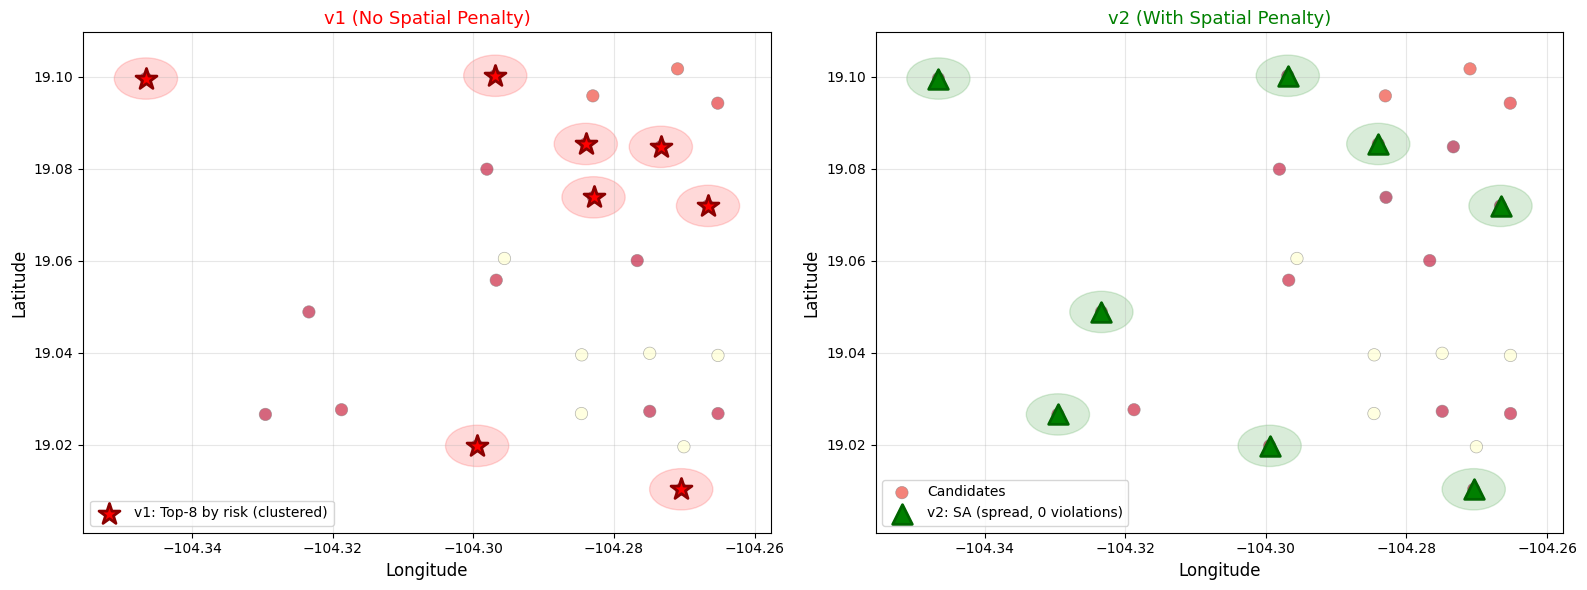

Before/after plot saved


In [10]:
# ── 6. Before/After visualization ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: v1 behavior (no spatial penalty) — simulate by just picking top-K by risk
v1_greedy_idx = np.argsort(r)[::-1][:K_BUDGET]
axes[0].scatter(lons, lats, c=risk_norm, cmap='YlOrRd', s=80,
                edgecolors='gray', linewidths=0.5, zorder=2, alpha=0.6)
axes[0].scatter(lons[v1_greedy_idx], lats[v1_greedy_idx],
                c='red', s=250, marker='*', edgecolors='darkred',
                linewidths=2, zorder=5, label=f'v1: Top-{K_BUDGET} by risk (clustered)')
axes[0].set_xlabel('Longitude', fontsize=12)
axes[0].set_ylabel('Latitude', fontsize=12)
axes[0].set_title('v1 (No Spatial Penalty)', fontsize=13, color='red')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Draw 500m radius circles around v1 selections to show overlap
for idx in v1_greedy_idx:
    # Approximate: 500m ≈ 0.0045° at this latitude
    circle = plt.Circle((lons[idx], lats[idx]), 0.0045, color='red', alpha=0.15, zorder=1)
    axes[0].add_patch(circle)

# Plot 2: v2 behavior (with spatial penalty)
axes[1].scatter(lons, lats, c=risk_norm, cmap='YlOrRd', s=80,
                edgecolors='gray', linewidths=0.5, zorder=2, alpha=0.6, label='Candidates')

# Plot best SA solution
sa_sel = np.where(x_sa_best == 1)[0]
axes[1].scatter(lons[sa_sel], lats[sa_sel],
                c='green', s=200, marker='^', edgecolors='darkgreen',
                linewidths=2, zorder=5, label=f'v2: SA (spread, {sa_results[best_sa_idx]["violations"]} violations)')

# Draw 500m radius circles
for idx in sa_sel:
    circle = plt.Circle((lons[idx], lats[idx]), 0.0045, color='green', alpha=0.15, zorder=1)
    axes[1].add_patch(circle)

axes[1].set_xlabel('Longitude', fontsize=12)
axes[1].set_ylabel('Latitude', fontsize=12)
axes[1].set_title('v2 (With Spatial Penalty)', fontsize=13, color='green')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'sensor_placement_before_after_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Before/after plot saved')

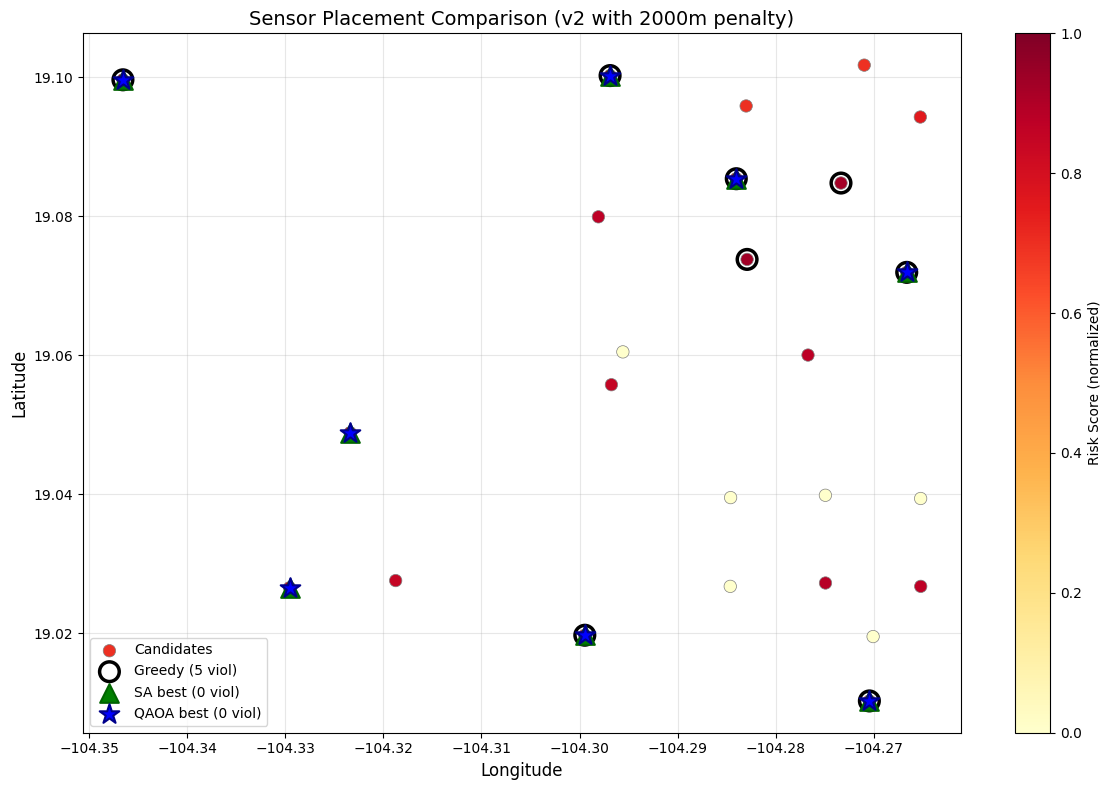

Comparison plot saved


In [11]:
# ── 6B. Solver comparison plot (all three on one map) ───────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(lons, lats, c=risk_norm, cmap='YlOrRd', s=80,
           edgecolors='gray', linewidths=0.5, zorder=2, label='Candidates')
plt.colorbar(ax.collections[0], ax=ax, label='Risk Score (normalized)')

# Greedy
greedy_sel = np.where(x_greedy == 1)[0]
ax.scatter(lons[greedy_sel], lats[greedy_sel],
           facecolors='none', edgecolors='black', s=200,
           linewidths=2.5, zorder=3, label=f'Greedy ({greedy_stats["violations"]} viol)')

# SA best
ax.scatter(lons[sa_sel], lats[sa_sel],
           c='green', s=180, marker='^', edgecolors='darkgreen',
           linewidths=1.5, zorder=4, label=f'SA best ({sa_results[best_sa_idx]["violations"]} viol)')

# QAOA best
if x_qaoa_best is not None:
    qaoa_sel = np.where(x_qaoa_best == 1)[0]
    ax.scatter(lons[qaoa_sel], lats[qaoa_sel],
               c='blue', s=220, marker='*', edgecolors='darkblue',
               linewidths=1.5, zorder=5, label=f'QAOA best ({qaoa_results[best_qaoa_idx]["violations"]} viol)')

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(f'Sensor Placement Comparison (v2 with {MIN_SEPARATION_M}m penalty)', fontsize=14)
ax.legend(fontsize=10, loc='best')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PROC, 'sensor_placement_comparison_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Comparison plot saved')